<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

## Objetivo: identificar patrones que determinen si un juego tiene éxito o no.
Procedimiento:
1. Se leen los datos
2. Se preparan (procesar los valores nulos y repetidos, snake_case, elegir los tipos necesarios de datos, agregar datos)
3. analizar los datos: diferencias de publicación por año,ventas por plataforma, tiempo de desaparición de una plataforma, elegir rangos de tiempo significativos, mejores plataformas, reseñas y ventas. Así como gráficos para poder responder.
4. Crear perdiles por región: top5 plataformas, top5 generos, relación entre clasificación y ventas
5. pruebas de hipostesis

## 1. Apertura de los datos y examinación

In [1]:

import pandas as pd          

import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns        
from scipy import stats

Se importan las librerias que podrían ser utiles.

In [2]:
complete_data = pd.read_csv('/datasets/games.csv')

In [3]:
complete_data.info()
print(complete_data.sample(7))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
                                                    Name Platform  \
8155                             Tomb Raider: Underworld      PS2   
1269                                       Madden NFL 09      PS2   
2975                              

Se revisa el estado del DF:
De él se puede deducir que hay valores nulos, que los nombres de las columnas no estan en snake_case,que el año de lanzamiento y otras columnas podrían cambiar de tipo.

## 2. Preparación de los datos

In [4]:
complete_data.columns = complete_data.columns.str.lower()
print(complete_data.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


*Aquí se cambió el nombre de las columnas para que estuvieran en snake_case



In [5]:
data_2005_plus = complete_data[complete_data['year_of_release'] >= 2005].copy()
print("Datos desde 2005:")
print(f"Total de juegos: {len(data_2005_plus)}")
print("\nPorcentaje de valores nulos:")
for col in ['critic_score', 'user_score', 'rating']:
    null_pct = (data_2005_plus[col].isnull().sum() / len(data_2005_plus)) * 100
    print(f"{col}: {null_pct:.1f}%")

Datos desde 2005:
Total de juegos: 11272

Porcentaje de valores nulos:
critic_score: 49.9%
user_score: 34.5%
rating: 35.1%


Aquí revisé el estado de diferentes años para determinar cual era el mejor para comenzar el analisis. considerando que la mayoria de juegos antes del 2000 no tienen ningun tipo de score y que además, si lo que se busca es tener datos significativos, quizá lo más adecuado sería tener los datos de consolas de una generación anterior a la que se está analizando. Es decir, xbox360, ps3, wii y las portatiles que estén a la par. El año de lanzamiento del xbox360 es 2005 por lo que es la mejor opción para comenzar. De igual forma, esta consola es la que tiene un mayor ratio de score no nulos en el total de sus juegos, por lo que será la elegida para el analisis del sccater plot.

In [6]:
data_2005_plus['user_score'] = pd.to_numeric(data_2005_plus['user_score'], errors='coerce')
data_2005_plus['user_score'] = data_2005_plus['user_score'] * 10
data_2005_plus['critic_score'] = data_2005_plus['critic_score'].replace(['', ' ', 'tbd', 'TBD'], np.nan)

data_2005_plus['rating'] = data_2005_plus['rating'].fillna('unrated')

data_2005_plus['year_of_release'] = data_2005_plus['year_of_release'].astype('int')
data_2005_plus.info()
print(data_2005_plus.sample(5))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11272 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             11272 non-null  object 
 1   platform         11272 non-null  object 
 2   year_of_release  11272 non-null  int64  
 3   genre            11272 non-null  object 
 4   na_sales         11272 non-null  float64
 5   eu_sales         11272 non-null  float64
 6   jp_sales         11272 non-null  float64
 7   other_sales      11272 non-null  float64
 8   critic_score     5645 non-null   float64
 9   user_score       5538 non-null   float64
 10  rating           11272 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.0+ MB
                                 name platform  year_of_release         genre  \
4049   Middle-Earth: Shadow of Mordor     X360             2014        Action   
248                     Nintendo Land     WiiU             2012      

*se homogeneizó la clasificación entre el user_score y el critic_score a una escala de 100 pues se lée mejor

*Se cambió el tipo de dato el año a int, pues no tiene sentido tener decimales en el año

*Al hacer una selección a partir del 2005 los elementos nulos del resto de columnas (a excepción de los score y el rating) ya no son relevantes.

*Como la única tarea en la que se utilizarán los score es para hacer un scatter plot, no es necesario cambiar los valores nulos pues la función los ignora. Por lo tanto se cambiaron los valore tbd a NaN.

*En el caso del rating, al ser una entrada categorica se puede agregar una para los que no tienen rating a 'unrated'.

In [7]:
data_2005_plus['total_sales'] = (data_2005_plus['na_sales'] + data_2005_plus['eu_sales'] + data_2005_plus['jp_sales'] + data_2005_plus['other_sales'])
print(data_2005_plus.sample(2))


                        name platform  year_of_release genre  na_sales  \
7937           Face Training       DS             2007  Misc      0.00   
8515  Dancing With The Stars      PS2             2007  Misc      0.08   

      eu_sales  jp_sales  other_sales  critic_score  user_score   rating  \
7937      0.00      0.19         0.00           NaN         NaN  unrated   
8515      0.06      0.00         0.02           NaN         NaN     E10+   

      total_sales  
7937         0.19  
8515         0.16  


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Hiciste un buen trabajo al cambiar los nombres de las columnas, sus tipos de datos y reemplazar los valores ausentes
</div>


Se agrega una nueva columna 'total_sales' con la suma de las ventas por región. se imprimen dos ejemplos para ver la incorporación adecuada.

## 3. Analisis de los datos

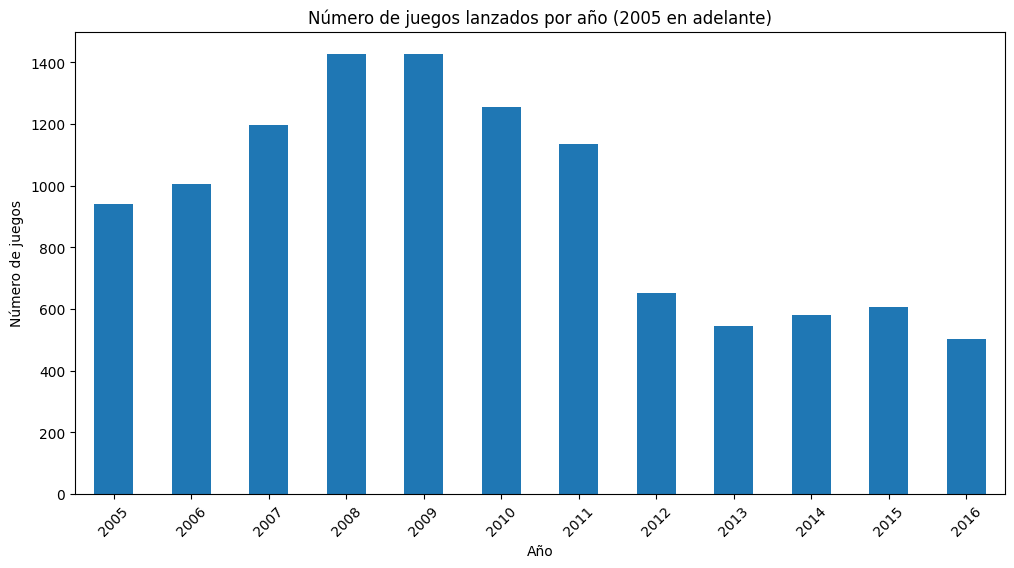

In [8]:
games_per_year = data_2005_plus['year_of_release'].value_counts().sort_index()


plt.figure(figsize=(12, 6))
games_per_year.plot(kind='bar')
plt.title('Número de juegos lanzados por año (2005 en adelante)')
plt.xlabel('Año')
plt.ylabel('Número de juegos')
plt.xticks(rotation=45)
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>

Buena manera de presentar los datos, podemos ver claramente la tendencia de los videojuegos con un incremento constante en años anteriores que ha empezado a ir en declive en los últimos años
</div>


*Se observa que los años 2008 y 2009 tiene más videojuegos lanzados.

*La curva baja a partir del 2012, probablemente porque los juegos de consolas más recientes (al periodo de análisis) tienen un tiempo de desarrollo mayor.

In [9]:
platform_sales = data_2005_plus.groupby('platform')['total_sales'].sum().sort_values(ascending = False)
print(platform_sales)

platform
X360    961.24
PS3     931.34
Wii     891.18
DS      785.49
PS2     426.46
PS4     314.14
PSP     282.47
3DS     257.81
PC      167.79
XOne    159.32
WiiU     82.19
XB       59.85
PSV      53.81
GBA      42.54
GC       39.15
DC        0.06
Name: total_sales, dtype: float64


In [10]:

top_5_platforms = ['X360', 'PS3', 'Wii', 'DS', 'PS2']


top_5_data = data_2005_plus[data_2005_plus['platform'].isin(top_5_platforms)]

print(f"Datos filtrados: {len(top_5_data)} juegos")
print("Plataformas incluidas:", top_5_data['platform'].unique())

sales_by_year_platform = top_5_data.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

print("Primeras filas del agrupamiento:")
print(sales_by_year_platform.head(10))

Datos filtrados: 6986 juegos
Plataformas incluidas: ['Wii' 'DS' 'X360' 'PS3' 'PS2']
Primeras filas del agrupamiento:
  platform  year_of_release  total_sales
0       DS             2005       130.14
1       DS             2006       119.81
2       DS             2007       146.94
3       DS             2008       145.31
4       DS             2009       119.54
5       DS             2010        85.02
6       DS             2011        26.18
7       DS             2012        11.01
8       DS             2013         1.54
9      PS2             2005       160.66


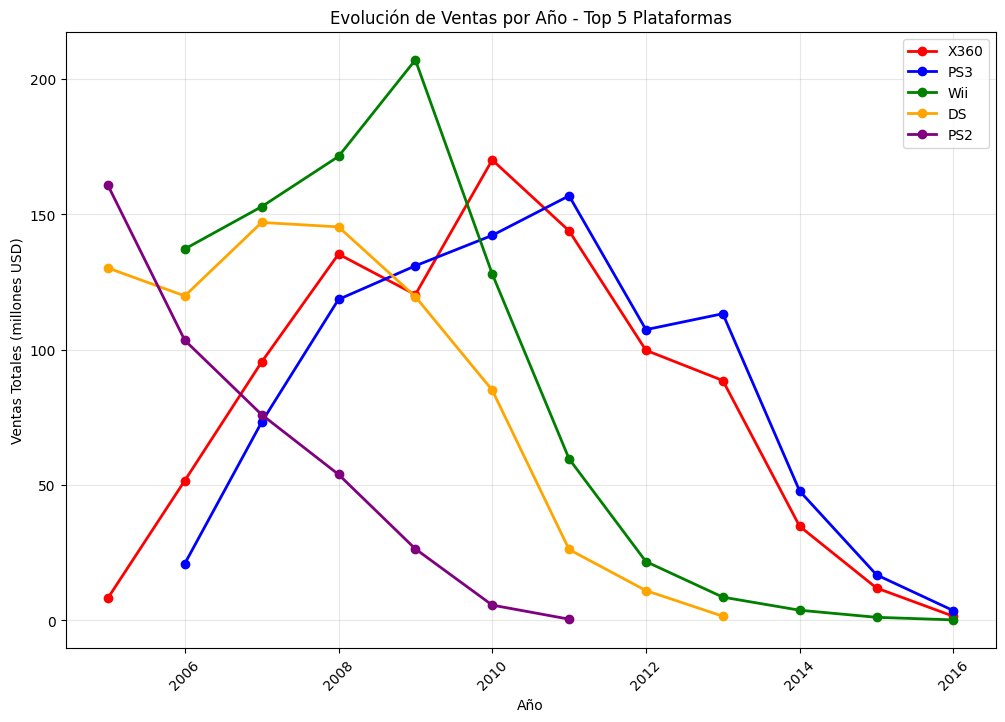

In [11]:

plt.figure(figsize=(12, 8))


colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, platform in enumerate(top_5_platforms):
    platform_data = sales_by_year_platform[sales_by_year_platform['platform'] == platform]
    
    plt.plot(platform_data['year_of_release'], 
             platform_data['total_sales'],
             marker='o',                    
             linewidth=2,
             label=platform,
             color=colors[i])

plt.xlabel('Año')
plt.ylabel('Ventas Totales (millones USD)')
plt.title('Evolución de Ventas por Año - Top 5 Plataformas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Buena manera de mostrar los datos, gracias a la gráfica podemos darnos una idea del ciclo de vida de cada una de las plataformas
</div>


Aquí se pueden observar varios aspectos

* El primero es que las plataformas como DS o PS2 vendieron mucho en su ciclo, pero para el periodo considerado estas ya estan en su declive.

* En ese mismo sentido es posible ver el comportamiento de una generación completa el xbox360, ps3 y wii en el que se observa que **hay un ciclo de unos diez años aproximadamente.** En el caso del wii su pico está en el tercer año (2009), mientras que para xbox360 y ps3 alcanzan su pico 5 años despues de su lanzamiento 2010 y 2011 respectivamente. Algo relevante es que la consola wii tuvo un declive más rapido que su competencia, pues sus ventas para el 2011 ya estan muy por debajo de su competencia.

* El año de lanzamiento del ps2 fue en el 2000, por lo que el ciclo parece ser aplicable. El DS se lanza en 2004 por lo que su ciclo fue de 9 años.

* **Con base en estos datos, mi selección de 11 años para el análisis sugiere ser la correcta**

* Ahora lo siguiente, si consideramos que hay un ciclo de vida que tiene aproximadamente 10 años, las consolas de reciente creacion (para el periodo de análisis) deberian ser consideradas para el futuro, por ejemplo WiiU, ps4,xone, PC (pues no tiene un ciclo como tal). Podria observarse tambien el 3ds, como portatil de valor en ventas.

Datos filtrados: 5 juegos
Plataformas incluidas: ['PS4' '3DS' 'PC' 'XOne' 'WiiU']


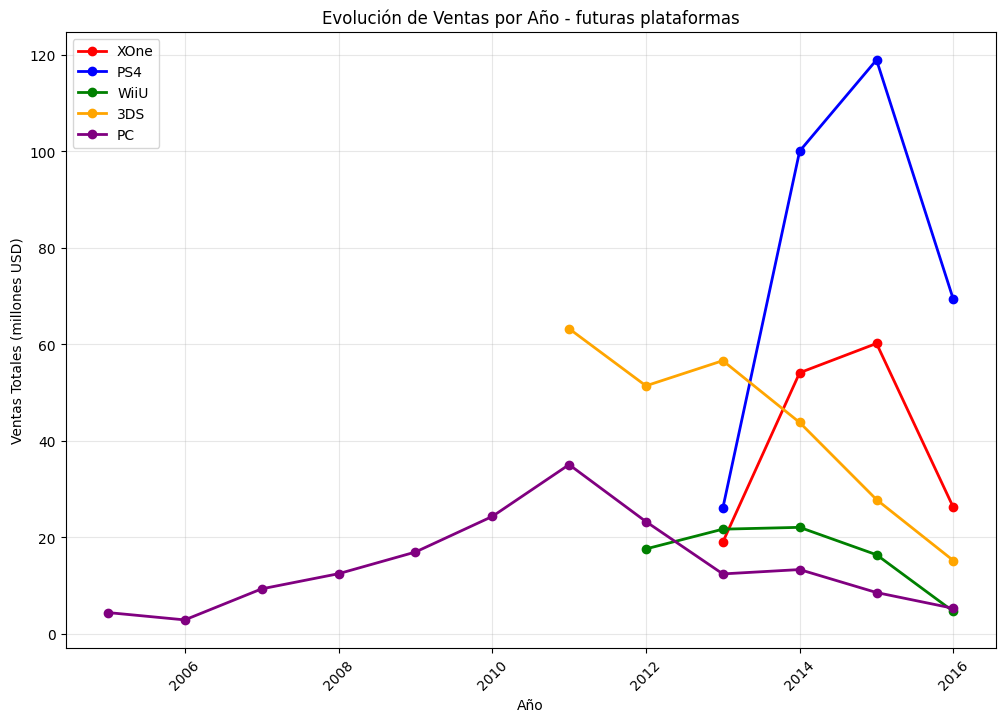

In [12]:
future_platforms = ['XOne', 'PS4', 'WiiU', '3DS', 'PC']


future_data = data_2005_plus[data_2005_plus['platform'].isin(future_platforms)]

print(f"Datos filtrados: {len(future_platforms)} juegos")
print("Plataformas incluidas:", future_data['platform'].unique())

sales_by_year_future_platform = future_data.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

#Gráfico
plt.figure(figsize=(12, 8))


colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, platform in enumerate(future_platforms):
    platform_data = sales_by_year_future_platform[sales_by_year_future_platform['platform'] == platform]
    
    plt.plot(platform_data['year_of_release'], 
             platform_data['total_sales'],
             marker='o',                    
             linewidth=2,
             label=platform,
             color=colors[i])

plt.xlabel('Año')
plt.ylabel('Ventas Totales (millones USD)')
plt.title('Evolución de Ventas por Año - futuras plataformas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()


Con base en esta gráfica podemos ver lo siguiente:
* la PC es una plataforma transversal al tiempo, es decir que no tiene un ciclo de vida como tal, aunque parece que los juegos públicados sí tienen un pico de popularidad. Podría ser una plataforma rentable para la venta de juegos pues no dejan de venderse, a pesar de que su venta es menor.

* El 3DS parece que tuvo un ciclo de vida corto, pues auqnue no habria que considerar el periodo del 2016 pues los no estan completos ya se ve una tendencia a la baja.

* Lo mismo puede pensarse del WiiU pues sus ventas apenas superan las de la PC y su tendencia es a la baja.

* Por otro lado tanto PS3 como XOne, si tiene una tendencia a la alta, si bien parecen decaer en el 2016 puede ser porque los datos no esten completos. Considerando lo observado con la generación anterior, aun deberia haber un par de años en los que las ventas aumenten, por otro lado quizá el WiiU no es la mejor opción en la cual invertir pues las ganancias son muy bajas comparadas a su plataforma previa (wii).

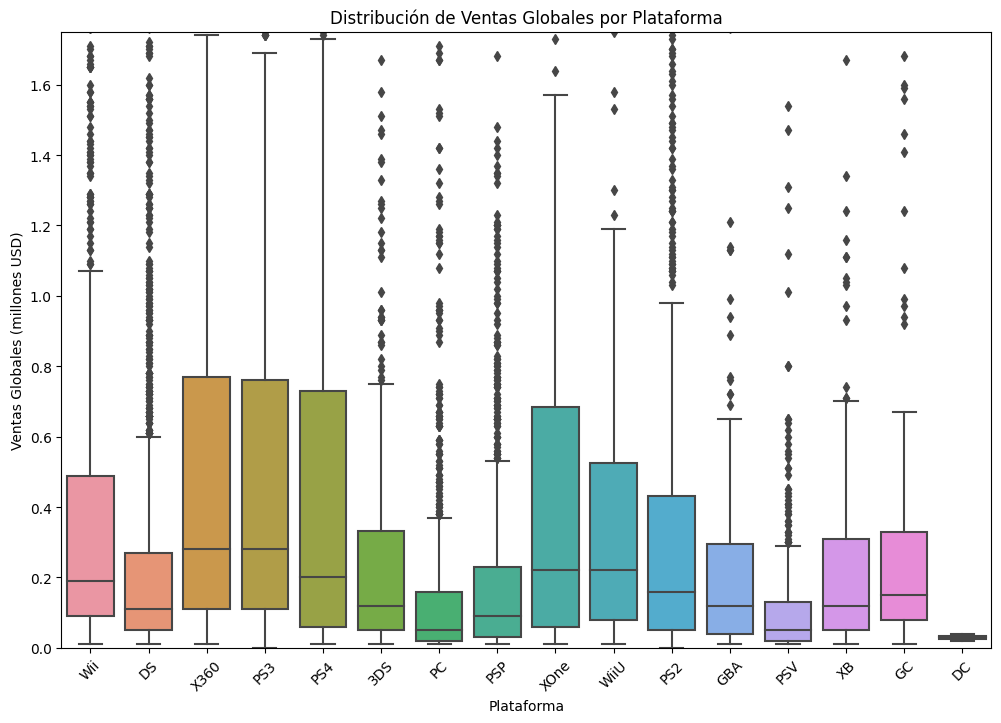

In [13]:
plt.figure(figsize=(12, 8))

# Crear boxplot por plataforma
sns.boxplot(data= data_2005_plus, x='platform', y='total_sales')
plt.ylim(0, 1.75) 
plt.xticks(rotation=45)
plt.title('Distribución de Ventas Globales por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales (millones USD)')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

El diagrama de caja nos muestra como en algunas plataformas las ventas estan consolidadas mientras que en otras consolas las ventas son muy disparejas lo que incrementa el rango intercuartil
</div>


Con el gráfico anterior es posible distinguir que hay muchos valores atipicos, sobre todo en los juegos más retanbles, pues son los que se escapan de los valores más comunes. Es por eso que constriñí el gráfico hasta los bigotes más lejanos, pues si se dejaba completo no se percibian las cajas.

* No obstante, algo que se puede apreciar es que el ventas de los juegos que se encuentran despues de la mediana, particularmente en el 3Q. Lo que implicaria que más de la mitad de los juegos tienen un exito de moderado a alto pues en el caso del x360 y del PS3 el ultimo 25% es aun más alto.

* Para el caso de las ventas de las "futuras consolas", se puede ver que WiiU tiene unadiferencia a XOne y PS4 pues a pesar de que la mediana es similar el resto de las ventas del segundo 50% son menores.


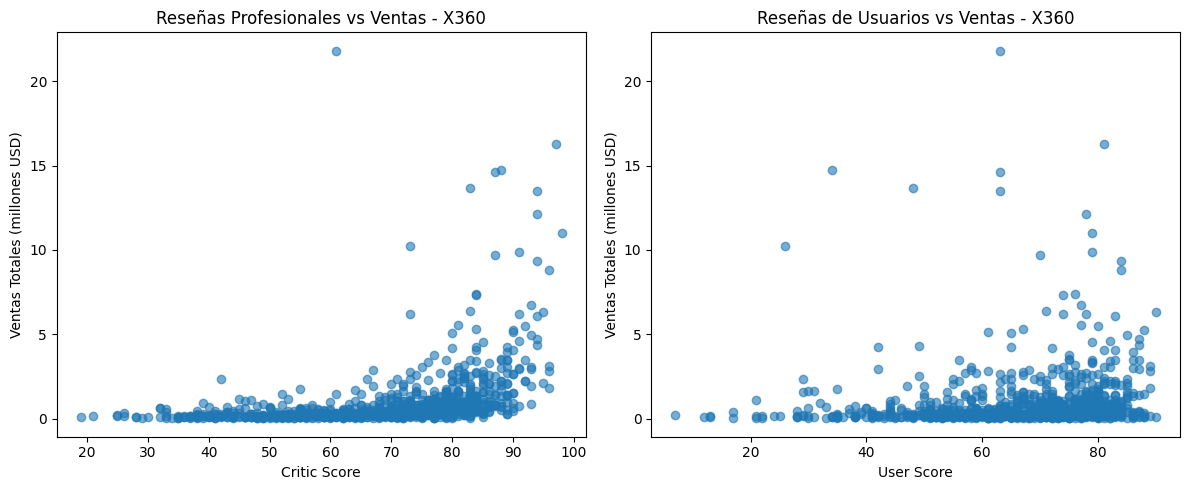

Correlación Critic Score - Ventas: 0.393
Correlación User Score - Ventas: 0.114


In [14]:

xbox_data = data_2005_plus[data_2005_plus['platform'] == 'X360']

plt.figure(figsize=(12, 5))

# Subplot 1: Critic Score vs Ventas
plt.subplot(1, 2, 1)
plt.scatter(xbox_data['critic_score'], xbox_data['total_sales'], alpha=0.6)
plt.xlabel('Critic Score')
plt.ylabel('Ventas Totales (millones USD)')
plt.title('Reseñas Profesionales vs Ventas - X360')

# Subplot 2: User Score vs Ventas
plt.subplot(1, 2, 2)
plt.scatter(xbox_data['user_score'], xbox_data['total_sales'], alpha=0.6)
plt.xlabel('User Score')
plt.ylabel('Ventas Totales (millones USD)')
plt.title('Reseñas de Usuarios vs Ventas - X360')

plt.tight_layout()
plt.show()

#comprobar correlación
corr_critic = xbox_data['critic_score'].corr(xbox_data['total_sales'])
corr_user = xbox_data['user_score'].corr(xbox_data['total_sales'])

print(f"Correlación Critic Score - Ventas: {corr_critic:.3f}")
print(f"Correlación User Score - Ventas: {corr_user:.3f}")


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de mostrar la correlación entre las ventas y las reseñas, como bien mencionas las correlaciones son debil-moderada por lo que no siempre las buenas reseñas van a implicar un gran numero de ventas
</div>


Como ya se refería previamente, se eligió el x360 pues es una consola con un ciclo completo, antecede una generación a las consolas actuales (para el periodo de análisis) y es la que tenia un mejor ratio de puntos validos en relación a los valores ausentes.

Este gráfico de dispersión y las métricas de correlación nos dan algunas pistas repsecto a la influencia de las calificaciones (score) de los usuarios y de los críticos.

* Lo primero es que parece haber una correlación baja-moderada de las ventas con las reseñas de los críticos pues apenas alcanza el .4
* En el caso de las ventas en relación a la calificacón de los usuarios esta casi nula. pues apenas supera el .1
* Parece ser que la crítica tiene un cierto valor pero esto no es garantia de mucho.


In [15]:
genre_counts = data_2005_plus['genre'].value_counts()
print("Cantidad de juegos por género:")
print(genre_counts)

genre_sales = data_2005_plus.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
print("Ventas totales por género:")
print(genre_sales)

genre_avg_sales = data_2005_plus.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
print("Ventas promedio por género:")
print(genre_avg_sales)

Cantidad de juegos por género:
Action          2574
Sports          1383
Misc            1368
Role-Playing    1067
Adventure       1065
Shooter          833
Simulation       644
Racing           638
Fighting         456
Platform         423
Strategy         422
Puzzle           399
Name: genre, dtype: int64
Ventas totales por género:
genre
Action          1202.04
Sports           853.34
Shooter          758.56
Misc             615.83
Role-Playing     550.78
Racing           355.03
Platform         303.06
Simulation       269.62
Fighting         208.07
Adventure        149.81
Puzzle           110.28
Strategy          78.42
Name: total_sales, dtype: float64
Ventas promedio por género:
genre
Shooter         0.910636
Platform        0.716454
Sports          0.617021
Racing          0.556473
Role-Playing    0.516195
Action          0.466993
Fighting        0.456294
Misc            0.450168
Simulation      0.418665
Puzzle          0.276391
Strategy        0.185829
Adventure       0.140667
Na

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de presentar los datos, podemos ver claramente cuales son los géneros preferidos de las personas, las observaciones que haces me parecen buenas también
</div>


De las siguientes métricas podemos ver que aunque la cantidad de juegos pueblicados el top5 de generos está [Action, Sports, Misc, Role-Playing,
Adventure] al ver las ventas los resultados cambian teniendo en el top5 a [Action, sport, shooter, misc y role-playing] sin embargo hay que tener en consideración dos cosas.
1. misc es un termino para colocar juegos de diferentes generos que no entran en las categorias convencionales, por lo que no nos da mucho indicio sobre que tipo de juegos son, a la hora de elegir los que se venderan.
2. Lo relevante para la tienda no es que tipo de genero vende más sino que juegos de cierto tipo se venden más, por lo que conviene ver los promedios de venta más que las ventas totales.
De esta manera las ventas promedio ponen el enfasis en los siguientes generos: **Shooter, Platform, Sports, Racing, Role-Playing.**

In [16]:

platforms_of_interest = ['X360', 'PS3', 'Wii']
multi_platform_data = data_2005_plus[data_2005_plus['platform'].isin(platforms_of_interest)]


pivot_table = multi_platform_data.pivot_table(
    index='name', 
    columns='platform', 
    values='total_sales', 
    aggfunc='sum'
)

just_multi_games = pivot_table.dropna().copy()
#Ventas totales por plataforma
platform_totals = just_multi_games[['PS3', 'Wii', 'X360']].sum()
print(f"\nVentas totales por plataforma:")
for platform in platform_totals.index:
    print(f"{platform}: {platform_totals[platform]:.2f}M")

#ver los 5 juegos más vendidos
just_multi_games['total_ventas'] = just_multi_games.sum(axis=1)


top_10_games = just_multi_games.nlargest(10, 'total_ventas')
print("Top 10 juegos más vendidos en las 3 plataformas:")
print(top_10_games)


Ventas totales por plataforma:
PS3: 205.08M
Wii: 174.35M
X360: 214.35M
Top 10 juegos más vendidos en las 3 plataformas:
platform                             PS3    Wii   X360  total_ventas
name                                                                
Call of Duty: Modern Warfare 3     13.33   0.83  14.73         28.89
Call of Duty: Black Ops            12.63   1.37  14.62         28.62
Call of Duty: World at War          5.39   1.93   7.38         14.70
FIFA Soccer 13                      8.17   0.69   5.16         14.02
Just Dance 3                        0.62  10.12   2.02         12.76
FIFA 12                             6.64   0.76   4.17         11.57
Guitar Hero III: Legends of Rock    2.25   4.58   4.53         11.36
FIFA 14                             6.46   0.38   4.22         11.06
LEGO Star Wars: The Complete Saga   2.28   5.63   2.58         10.49
FIFA Soccer 11                      5.07   1.07   3.52          9.66


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de mostrar los resultados, pdemos ver como los usuarios tienen preferencias por algunos videojuegos en ciertas plataformas, lo que nos ayuda a entender mejor al mercado
</div>


Si se obserban los datos por plataforma, vemos que el PS3 vende más juegos que estan en las tres plataformas.
No obstante, si se ve el top 10 de juegos multiplataforma más vendidos se puede observar que hay diferencias: 
* Los shooters parecen venderse más en x360 (lo cual puede deberse a su plataforma para jugar online, más confiable que la de PS3)
* Los FIFA se vende más en PS3
* Juegos más familiares se vende más en wii
Parece que hay que hacer un analisis por genero, por plataforma y probablemente por región para profundizar en estos resultados.


## 4. Perfiles de usuario por región

In [17]:

def analyze_region(data, region_column, region_name):
    print(f"\n=== PERFIL DE USUARIO - {region_name.upper()} ===")
    
    
    platform_sales = data.groupby('platform')[region_column].sum().sort_values(ascending=False)
    print(f"\nTop 5 plataformas en {region_name}:")
    print(platform_sales.head())
    
    
    genre_sales = data.groupby('genre')[region_column].sum().sort_values(ascending=False)
    print(f"\nTop 5 géneros en {region_name}:")
    print(genre_sales.head())
    
    
    rating_sales = data.groupby('rating')[region_column].sum().sort_values(ascending=False)
    print(f"\nVentas por clasificación ESRB en {region_name}:")
    print(rating_sales)
    
    return platform_sales, genre_sales, rating_sales

na_platforms, na_genres, na_ratings = analyze_region(data_2005_plus, 'na_sales', 'Norteamérica')
eu_platforms, eu_genres, eu_ratings = analyze_region(data_2005_plus, 'eu_sales', 'Europa') 
jp_platforms, jp_genres, jp_ratings = analyze_region(data_2005_plus, 'jp_sales', 'Japón')



=== PERFIL DE USUARIO - NORTEAMÉRICA ===

Top 5 plataformas en Norteamérica:
platform
X360    595.74
Wii     486.87
PS3     390.13
DS      371.98
PS2     200.49
Name: na_sales, dtype: float64

Top 5 géneros en Norteamérica:
genre
Action          580.04
Sports          432.70
Shooter         400.96
Misc            311.82
Role-Playing    211.85
Name: na_sales, dtype: float64

Ventas por clasificación ESRB en Norteamérica:
rating
E          873.10
M          607.34
T          479.08
E10+       343.02
unrated    323.49
EC           1.53
AO           1.26
RP           0.00
Name: na_sales, dtype: float64

=== PERFIL DE USUARIO - EUROPA ===

Top 5 plataformas en Europa:
platform
PS3     327.21
X360    268.32
Wii     258.32
DS      184.48
PS4     141.09
Name: eu_sales, dtype: float64

Top 5 géneros en Europa:
genre
Action     372.58
Sports     265.61
Shooter    248.07
Misc       167.09
Racing     129.05
Name: eu_sales, dtype: float64

Ventas por clasificación ESRB en Europa:
rating
E         

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Los resultados mostrados me parecen correctos, recomiendo acompañarlos con gráficas que resalten las similitudes/diferencias de las regiones
</div>


**Análisis**

Segun los datos:
**Norteamérica** gusta de los juegos de acción, deportes y disparos. 
* Se puede ver que el PS4 se hace un hueco en la región a pesar de tener poco tiempo en el mercado.
* Las clasificaciones más populares son las e(para todo mundo) y m (mayores de edad)
  
**Europa** gusta de generos similares aunuqe los consumen menos(ventas menores), aunuqe hace su apareción el genero de carreras.
* En cuanto a las plataformas, PS3 es más popular, a diferencia de Norteamérica
* Las clasificaciones tienen una distribución similar a Norteamérica
  
**Japón** Quizá es la región  más particular pues sus géneros son distintos a los de las otras regiones. Prefieren los juegos de rol y de plataformas (en relación a los shooters de las otras regiones)
* Los juegos sin clasificación son más comunes en Japón quizá porque muchos de sus juegos sólo se venden ahí y quizá no usan el sistema global
* otra cosa a destacar es el uso de consolas portatiles. Aquí DS, 3DS, PSP son más comunes. Es de remarcar que consumen más sus productos(tanto Sony como Nintendo son japonesas) Ninguna plataforma de Microsoft hace aparición en lo más vendido.

## 5. Pruebas de hipótesis

Primero hay que obsevar los datos

In [18]:
xone_data = data_2005_plus[(data_2005_plus['platform'] == 'XOne') & 
                           (data_2005_plus['user_score'].notna())]
pc_data = data_2005_plus[(data_2005_plus['platform'] == 'PC') & 
                         (data_2005_plus['user_score'].notna())]


xbox_scores = xone_data['user_score']
pc_scores = pc_data['user_score']

print("=== XBOX ONE ===")
print(f"Tamaño de muestra: {len(xbox_scores)}")
print(f"Media: {xbox_scores.mean():.3f}")
print(f"Mediana: {xbox_scores.median():.3f}")
print(f"Desviación estándar: {xbox_scores.std():.3f}")
print(f"Varianza: {xbox_scores.var():.3f}")

print("\n=== PC ===")
print(f"Tamaño de muestra: {len(pc_scores)}")
print(f"Media: {pc_scores.mean():.3f}")
print(f"Mediana: {pc_scores.median():.3f}")
print(f"Desviación estándar: {pc_scores.std():.3f}")
print(f"Varianza: {pc_scores.var():.3f}")


=== XBOX ONE ===
Tamaño de muestra: 182
Media: 65.214
Mediana: 68.000
Desviación estándar: 13.809
Varianza: 190.700

=== PC ===
Tamaño de muestra: 644
Media: 68.849
Mediana: 73.000
Desviación estándar: 15.158
Varianza: 229.755


In [19]:
ratio_varianzas = 190.700 / 229.755
print(f"Ratio de varianzas (Xbox/PC): {ratio_varianzas:.3f}")

Ratio de varianzas (Xbox/PC): 0.830


H0 = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

H1 = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC no son las mismas.


In [20]:
from scipy.stats import ttest_ind


t_stat, p_value = ttest_ind(xbox_scores, pc_scores, equal_var=True)


alpha = 0.05

print("=== PRUEBA DE HIPÓTESIS ===")
print(f"H₀: μ_Xbox = μ_PC")
print(f"H₁: μ_Xbox ≠ μ_PC")
print(f"\nEstadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nivel de significancia (α): {alpha}")


if p_value < alpha:
    print(f"\nDECISIÓN: Rechazar H₀ (p = {p_value:.6f} < α = {alpha})")
    print("CONCLUSIÓN: Hay evidencia significativa de que las medias son diferentes")
else:
    print(f"\nDECISIÓN: No rechazar H₀ (p = {p_value:.6f} ≥ α = {alpha})")
    print("CONCLUSIÓN: No hay evidencia suficiente para concluir que las medias son diferentes")


=== PRUEBA DE HIPÓTESIS ===
H₀: μ_Xbox = μ_PC
H₁: μ_Xbox ≠ μ_PC

Estadístico t: -2.9116
Valor p: 0.003693
Nivel de significancia (α): 0.05

DECISIÓN: Rechazar H₀ (p = 0.003693 < α = 0.05)
CONCLUSIÓN: Hay evidencia significativa de que las medias son diferentes


Para esta prueba primero observamos los valores estadisticos de las variables (las calificaciones de usuario en XONE y PC)
* Como se observó, el tamaño de la muestra es diferente, pero la hipótesis iba detrás de la media por lo que la prueba t es una opción adecuada pues puede lidiar con muestras de distintos tamaños.
* Se optó por un alpha de .5 pues es el estandar
* Al ver el ratio de varianzas se determinó que podrian considerarse como *iguales*
* Al observar los resultados de la prueba se observa que las diferencias en la media son significativamente distintas por lo que no deberiamos considerar que esto es información que se deba valorar en su conjunto.

Para la siguiente prueba se usan las siguientes:



H0 = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.

H1 = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.



In [21]:
action_data = data_2005_plus[(data_2005_plus['genre'] == 'Action') & 
                           (data_2005_plus['user_score'].notna())]
sports_data = data_2005_plus[(data_2005_plus['genre'] == 'Sports') & 
                         (data_2005_plus['user_score'].notna())]


action_scores = action_data['user_score']
sports_scores = sports_data['user_score']

print("=== ACTION ===")
print(f"Tamaño de muestra: {len(action_scores)}")
print(f"Media: {action_scores.mean():.3f}")
print(f"Mediana: {action_scores.median():.3f}")
print(f"Desviación estándar: {action_scores.std():.3f}")
print(f"Varianza: {action_scores.var():.3f}")

print("\n=== SPORTS ===")
print(f"Tamaño de muestra: {len(sports_scores)}")
print(f"Media: {sports_scores.mean():.3f}")
print(f"Mediana: {sports_scores.median():.3f}")
print(f"Desviación estándar: {sports_scores.std():.3f}")
print(f"Varianza: {sports_scores.var():.3f}")

ratio_varianzas = 186.842 / 268.954
print(f"\nRatio de varianzas (Action/Sports): {ratio_varianzas:.3f}")

=== ACTION ===
Tamaño de muestra: 1463
Media: 69.470
Mediana: 72.000
Desviación estándar: 13.669
Varianza: 186.842

=== SPORTS ===
Tamaño de muestra: 757
Media: 65.395
Mediana: 69.000
Desviación estándar: 16.400
Varianza: 268.954

Ratio de varianzas (Action/Sports): 0.695


In [22]:
t_stat, p_value = ttest_ind(action_scores, sports_scores, equal_var=True)


alpha = 0.05

print("=== PRUEBA DE HIPÓTESIS ===")
print(f"H₀: μ_Action = μ_Sports")
print(f"H₁: μ_Action ≠ μ_Sports")
print(f"\nEstadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nivel de significancia (α): {alpha}")


if p_value < alpha:
    print(f"\nDECISIÓN: Rechazar H₀ (p = {p_value:.6f} < α = {alpha})")
    print("CONCLUSIÓN: Hay evidencia significativa de que las medias son diferentes")
else:
    print(f"\nDECISIÓN: No rechazar H₀ (p = {p_value:.6f} ≥ α = {alpha})")
    print("CONCLUSIÓN: No hay evidencia suficiente para concluir que las medias son diferentes")


=== PRUEBA DE HIPÓTESIS ===
H₀: μ_Action = μ_Sports
H₁: μ_Action ≠ μ_Sports

Estadístico t: 6.2102
Valor p: 0.000000
Nivel de significancia (α): 0.05

DECISIÓN: Rechazar H₀ (p = 0.000000 < α = 0.05)
CONCLUSIÓN: Hay evidencia significativa de que las medias son diferentes


Para esta segunda prueba se siguió el mismo procedimiento que con la prueba anterior.

* Como se observó, el tamaño de la muestra es diferente, pero la hipótesis iba detrás de la media por lo que la prueba t es una opción adecuada pues puede lidiar con muestras de distintos tamaños.
* Se optó por un alpha de .5 pues es el estandar
* Al ver el ratio de varianzas se determinó que podrian considerarse como iguales
*Al observar los resultados de la prueba se observa que las diferencias en la media son significativamente distintas por lo que no deberiamos considerar los juegos de deportes y de action en el mismo análisis. Al menos no en el sentido de las calificaciones de los usuarios.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />


El planteamiento de las pruebas de hipótesis me parecen correcto, bien hecho!
</div>


## 6. Conclusiones

A lo largo de todo el proyecto se fueron dejando las conclusiones a las incognitas del proyecto.
Aquì sòlo se hace un resumen:
1. se abrieron los datos y se observaron los datos nulos, los problemas con el nombre de las columnas y el tipo de datos de algunas de estas.
2. se arreglaron los datos para un mejor análisis:
* se corrigieron los nombres de las columnas y su tipo de datos.
* se decidiño poner en NaN los valores ausentes o por determinar en los score, pues los metodos con los que se utilizarìan a lo largo del proyecto no tendrían problema con manejarlos. Al contrario de que si los llenabamos podrian alterar los valores reales.
* en el caso de los raitings se creó una nueva categoria unrated, pues es columna tenia valores categóricos.
  
3. En este paso se analizaron los datos y se dieron distintos insights:
* se observó que los datos màs utiles para nuestros propositos eran aquellos posteriores al 2005, pues las consolas de generacion pasada tuvieron su cilo de vida a partir de ese periodo. Su similitud con las plataformas màs actuales es más parecido
* con la gráfica que observa las ventas de las consolas en esos 11 años se pudo observar lo anterior, el ciclo de vida con un pico en 5 años posterior a su lanzamiento y su declive posterior.
* Así mismo, se observaron las tendencias de las nuevas consolas: **a la alza PS4 y XOne** a la baja el wiiU.
* **Se puede ver que los productos màs rentables resultarian ser: PS4 y XOne, auqnue la PC vende poco es estable.**
* **Las reseñas de los crìticos parecen tener una relaciòn con las ventas pero no es demasiada, es de baja a moderada por lo que una estrategia a partir de ahì puede ser util mas no crucial**
* Despuès con base en los juegos multiplataforma se observò que hay preferencias. Shooters se venden màs en XBOX, juegos familiares en Wii, deportes, los juegos de deporte parecen venderse màs en PS3 y probablemente tambien en PS4. Pero es mejor ver esto por región.
  
4. **Norteamérica** gusta de los juegos de acción, deportes y disparos. 
* Se puede ver que el PS4 se hace un hueco en la región a pesar de tener poco tiempo en el mercado.
* Las clasificaciones más populares son las e(para todo mundo) y m (mayores de edad)
  
**Europa** gusta de generos similares aunuqe los consumen menos(ventas menores), aunuqe hace su apareción el genero de carreras.
* En cuanto a las plataformas, PS3 es más popular, a diferencia de Norteamérica
* Las clasificaciones tienen una distribución similar a Norteamérica
  
**Japón** Quizá es la región  más particular pues sus géneros son distintos a los de las otras regiones. Prefieren los juegos de rol y de plataformas (en relación a los shooters de las otras regiones)
* Los juegos sin clasificación son más comunes en Japón quizá porque muchos de sus juegos sólo se venden ahí y quizá no usan el sistema global
* otra cosa a destacar es el uso de consolas portatiles. Aquí DS, 3DS, PSP son más comunes. Es de remarcar que consumen más sus productos(tanto Sony como Nintendo son japonesas) Ninguna plataforma de Microsoft hace aparición en lo más vendido.

**Lo mejor para cada regiòn cambia, por lo que una estrategìa diferenciada en genero y plataforma con los datos anteriores podrìa ser una buena aproximaciòn a cada región.**

5. Al ver las pruebas de hipotesis se puede observar que hay diferencias en los promedios  en realciòn a los score de xOne y PC, es decir no son iguales ni comparables. ASì mismo sucede con las medias de score entre juegos de acciòn y deportes, son significativamente distitnos.

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las observaciones que has hecho durante todo el ejercicio me han parecido bastante buenas, son un gran apoyo a la hora de revisar el proyecto ya que me dan a entender que el tema te ha quedado claro y has podido avanzar correctamente.

    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- El proyecto esta ordenado
    
</div>

<div class="alert alert-block alert-warning">
<b>Aspectos que pueden mejorar del proyecto</b> <a class="tocSkip"></a><br />

- Se pueden incluir más graficas para resaltar las observaciones o datos que muestras, especialmente en la parte donde se comparan las distintas regiones del mundo

</div>

